In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../')
print(sys.path[-3:])

['', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [2]:
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from networks.graph_attention_ffn_kan_multitask_updated import GraphAttentionKAN

plt.rcParams["figure.figsize"] = (8, 5)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.25
sns.set_context("notebook")

In [8]:


from sklearn.metrics import classification_report
import numpy as np

cm = np.array([
    [1946024,   758,     0,    87,   113,    25,   146,   153,    12,    23],
    [    446, 16570,     0,     0,     1,     2,     3,     8,     0,     0],
    [      0,     0, 10286,     0,     0,     0,     0,     0,     0,     0],
    [     80,     0,     0,  7269,     1,     2,     0,     0,     1,    76],
    [      8,     0,     0,     0,   935,     0,     0,     0,     0,     0],
    [      7,     0,     0,     0,     0, 21282,     0,     1,     0,     0],
    [     54,     2,     0,     0,     0,     0,  3288,     0,     0,     0],
    [     46,     4,     0,     0,     0,     3,     0,  3627,     0,     0],
    [      0,     0,     0,     0,     0,     0,     0,     0,  2143,     0],
    [     81,     0,     0,    43,     1,     0,     0,     0,     0,  4693]
])
y_true = []
y_pred = []

num_classes = cm.shape[0]
for i in range(num_classes):
  for j in range(num_classes):
    count = cm[i][j]
    y_true.extend([i] * count)
    y_pred.extend([j] * count)

target_names = ['Normal', 'Combined', 'DoS', 'Fuzzy', 'Gear', 'Interval', 'RPM', 'Speed', 'Standstill', 'Systematic']
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print("Classification Report: MRGAT-KAN \n", report)


print("False Negative Rate (FNR) per class:")
for i, name in enumerate(target_names):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    if (TP + FN) > 0:
        fnr = FN / (TP + FN)
    else:
        fnr = 0.0
    print(f"{name:12s}: {fnr*100:.2f}%")


Classification Report: MRGAT-KAN 
               precision    recall  f1-score   support

      Normal     0.9996    0.9993    0.9995   1947341
    Combined     0.9559    0.9730    0.9644     17030
         DoS     1.0000    1.0000    1.0000     10286
       Fuzzy     0.9824    0.9785    0.9804      7429
        Gear     0.8896    0.9915    0.9378       943
    Interval     0.9985    0.9996    0.9991     21290
         RPM     0.9566    0.9833    0.9698      3344
       Speed     0.9572    0.9856    0.9712      3680
  Standstill     0.9940    1.0000    0.9970      2143
  Systematic     0.9793    0.9741    0.9767      4818

    accuracy                         0.9989   2018304
   macro avg     0.9713    0.9885    0.9796   2018304
weighted avg     0.9989    0.9989    0.9989   2018304

False Negative Rate (FNR) per class:
Normal      : 0.07%
Combined    : 2.70%
DoS         : 0.00%
Fuzzy       : 2.15%
Gear        : 0.85%
Interval    : 0.04%
RPM         : 1.67%
Speed       : 1.44%
Standstil

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
def draw_confusion_matrix(cm, classes, save_dir=None):
    cm_df = pd.DataFrame(cm,
                     index = classes, 
                     columns = classes)
    mask = np.zeros_like(cm)
    np.fill_diagonal(mask, 1)
    plt.figure(figsize=(10,8))
    # sns.heatmap(cm_df, fmt='d', annot=True, cmap='YlGnBu', cbar=False, linewidths=0.5)
    sns.heatmap(cm_df, fmt='d', annot=True, cmap='YlGnBu', cbar=False, 
            linewidths=0.5, vmin=0, vmax=1000,)
    plt.xticks(rotation=45, ha='right')
    plt.title('MRGAT-KAN Node Classification')
    plt.ylabel('Actual Values')
    plt.xlabel('Predicted Values')
    # if save_dir is not None:
    #     plt.savefig(save_dir.format(ckpt_epoch), dpi=300, bbox_inches="tight", pad_inches=0.5)
    plt.show()

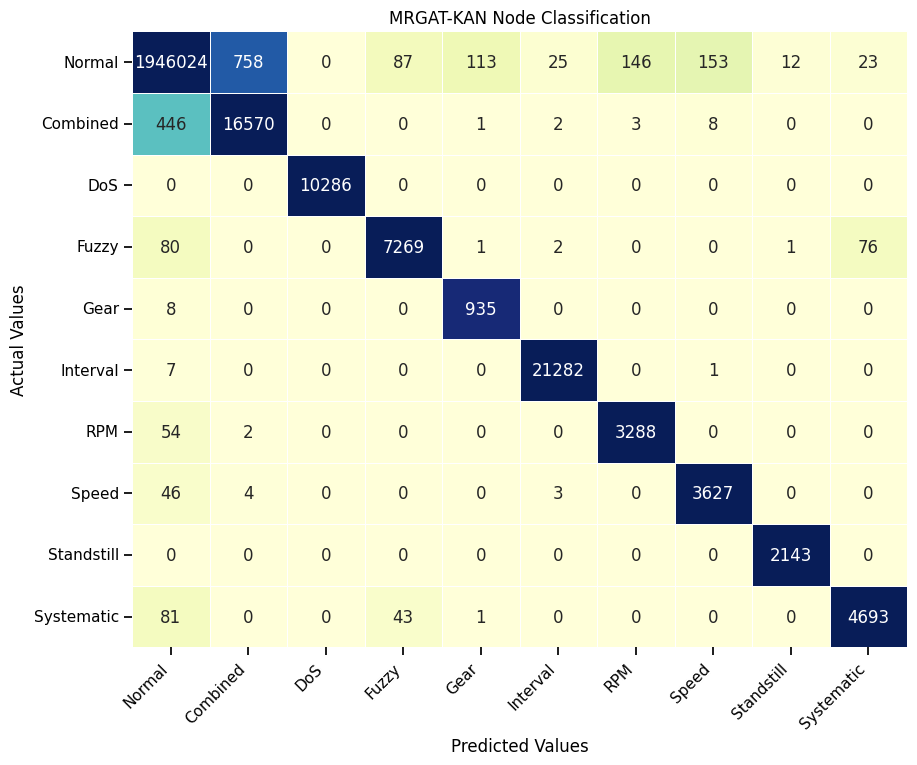

In [9]:
classes = ['Normal', 'Combined', 'DoS', 'Fuzzy', 'Gear', 'Interval', 'RPM', 'Speed', 'Standstill', 'Systematic']
draw_confusion_matrix(cm, classes)